In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import nltk, re, os, joblib, warnings
warnings.filterwarnings("ignore")

nltk.download("stopwords")
nltk.download("punkt")
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words("english"))
print("✅ Ready")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\VICTUS\AppData\Roaming\nltk_data...


✅ Ready


[nltk_data]   Package punkt is already up-to-date!


In [2]:
DATA_PATH = "../ml-service/data/crime_data.csv"

df = pd.read_csv(DATA_PATH)

if "year" not in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year

print(f"✅ Loaded {len(df):,} records  |  Years: {sorted(df['year'].dropna().unique().astype(int).tolist())}")
print(f"📋 Columns: {list(df.columns)}")
df.head()

✅ Loaded 9,800 records  |  Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
📋 Columns: ['incident_id', 'district', 'police_division', 'crime_type', 'date', 'day_of_week', 'is_holiday', 'time_bracket', 'location_type', 'lighting_level', 'victim_gender', 'victim_age_bracket', 'prior_offenses', 'offender_drug_history', 'reported_2015_total', 'solved_2015_total', 'cleared_rate_pct', 'reported_status', 'referral_source', 'year']


,incident_id,district,police_division,crime_type,date,day_of_week,is_holiday,time_bracket,location_type,lighting_level,victim_gender,victim_age_bracket,prior_offenses,offender_drug_history,reported_2015_total,solved_2015_total,cleared_rate_pct,reported_status,referral_source,year
0,2015-COL-001,Colombo,Colombo South,Homicide,2015-01-08,Thursday,Yes,Night,Public Space,Poorly-lit,Male,35-45,0,No,568,540,95,Solved,Police,2015
1,2015-COL-002,Colombo,Nugegoda,House Breaking,2015-04-14,Tuesday,Yes,Night,Residential,Dark,Female,45-60,1,No,9245,3050,33,Under Investigation,Police,2015
2,2015-GAM-001,Gampaha,Kelaniya,Drug Offences (Heroin),2015-02-15,Sunday,No,Morning,Transport Hub,Well-lit,Male,18-24,3,Yes,26145,25000,95,Solved,Police,2015
3,2015-KAN-001,Kandy,Kandy Central,Robbery,2015-08-10,Monday,No,Evening,Commercial,Well-lit,Male,25-35,2,No,3542,2300,65,Solved,Self-Reported,2015
4,2015-KAL-001,Kalutara,Panadura,Grievous Hurt,2015-03-22,Sunday,No,Evening,Public Space,Poorly-lit,Male,25-35,1,No,1410,1290,91,Solved,Hospital,2015


In [3]:
print("Crime type distribution:")
print(df["crime_type"].value_counts())

Crime type distribution:
crime_type
House Breaking                      1926
Drug Offences (Heroin)              1383
Robbery                             1287
Property Theft                      1256
Homicide                            1246
Grievous Hurt                        667
Drug Offences (Cannabis)             643
Cheating/BCT                         640
Statutory Rape                       602
Cattle Theft                          45
Drug Offences (Ice/Meth)              18
Extortion                              8
Drug Offences (Synthetic)              7
Crop Theft (Paddy)                     4
Financial Fraud (Pyramid Scheme)       4
Grievous Hurt (Protest related)        4
Arson                                  3
Mischief                               3
Unlawful Assembly                      2
Curfew Violation                       2
Financial Fraud (Online)               2
Robbery (Fuel/Essentials)              2
Property Theft (LPG Cylinder)          2
Robbery (Mobile Phone

In [4]:
def build_description(row):
    parts = []

    if pd.notna(row.get("district")):
        parts.append(f"occurred in {row['district']} district")
    if pd.notna(row.get("location_type")):
        parts.append(f"at a {row['location_type']}")
    if pd.notna(row.get("time_bracket")):
        parts.append(f"during {row['time_bracket']}")
    if pd.notna(row.get("lighting_level")):
        parts.append(f"with {row['lighting_level']} lighting")
    if pd.notna(row.get("victim_gender")):
        parts.append(f"victim was {row['victim_gender']}")
    if pd.notna(row.get("victim_age_bracket")):
        parts.append(f"aged {row['victim_age_bracket']}")
    if pd.notna(row.get("offender_drug_history")):
        parts.append(f"offender drug history {row['offender_drug_history']}")

    try:
        prior = float(row.get("prior_offenses", 0))
        if prior > 0:
            parts.append(f"offender had {int(prior)} prior offenses")
    except (ValueError, TypeError):
        pass

    holiday_val = str(row.get("is_holiday", "")).strip().lower()
    if holiday_val in ["1", "yes", "true"]:
        parts.append("incident occurred on a holiday")

    if pd.notna(row.get("referral_source")):
        parts.append(f"referred by {row['referral_source']}")
    if pd.notna(row.get("reported_status")):
        parts.append(f"status is {row['reported_status']}")
    if pd.notna(row.get("police_division")):
        parts.append(f"police division {row['police_division']}")
    if pd.notna(row.get("day_of_week")):
        parts.append(f"on {row['day_of_week']}")

    return ". ".join(parts)

df["description"] = df.apply(build_description, axis=1)

print("✅ Descriptions built WITHOUT crime_type label")
for _, row in df[["description","crime_type"]].head(3).iterrows():
    print(f"\n📝 {row['description'][:120]}")
    print(f"🏷️  Label: {row['crime_type']}")
    print("-" * 60)

✅ Descriptions built WITHOUT crime_type label

📝 occurred in Colombo district. at a Public Space. during Night. with Poorly-lit lighting. victim was Male. aged 35-45. of
🏷️  Label: Homicide
------------------------------------------------------------

📝 occurred in Colombo district. at a Residential. during Night. with Dark lighting. victim was Female. aged 45-60. offende
🏷️  Label: House Breaking
------------------------------------------------------------

📝 occurred in Gampaha district. at a Transport Hub. during Morning. with Well-lit lighting. victim was Male. aged 18-24. o
🏷️  Label: Drug Offences (Heroin)
------------------------------------------------------------


In [5]:
def clean_text(text):
    text   = str(text).lower()
    text   = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df["description"].apply(clean_text)

min_count     = 10
valid_classes = df["crime_type"].value_counts()
valid_classes = valid_classes[valid_classes >= min_count].index
df_model      = df[df["crime_type"].isin(valid_classes)].copy()

print(f"✅ Keeping {len(valid_classes)} classes, {len(df_model):,} records")
print(df_model["crime_type"].value_counts())

✅ Keeping 11 classes, 9,713 records
crime_type
House Breaking              1926
Drug Offences (Heroin)      1383
Robbery                     1287
Property Theft              1256
Homicide                    1246
Grievous Hurt                667
Drug Offences (Cannabis)     643
Cheating/BCT                 640
Statutory Rape               602
Cattle Theft                  45
Drug Offences (Ice/Meth)      18
Name: count, dtype: int64


In [6]:
X = df_model["clean_text"]
y = df_model["crime_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=20000,
        min_df=2,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=1.0,
        solver="lbfgs",
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
cv_acc = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy").mean()

print("=" * 45)
print(f"  Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print(f"  CV  Accuracy:  {cv_acc:.4f}  ({cv_acc*100:.2f}%)")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

  Test Accuracy: 0.9238  (92.38%)
  CV  Accuracy:  0.9082  (90.82%)

Classification Report:
                          precision    recall  f1-score   support

            Cattle Theft       1.00      1.00      1.00         9
            Cheating/BCT       0.98      1.00      0.99       128
Drug Offences (Cannabis)       0.98      0.88      0.93       129
  Drug Offences (Heroin)       0.93      0.90      0.91       277
Drug Offences (Ice/Meth)       0.00      0.00      0.00         4
           Grievous Hurt       0.99      0.99      0.99       133
                Homicide       1.00      1.00      1.00       249
          House Breaking       0.92      0.83      0.87       385
          Property Theft       1.00      0.99      0.99       251
                 Robbery       0.78      0.89      0.83       258
          Statutory Rape       1.00      1.00      1.00       120

                accuracy                           0.92      1943
               macro avg       0.87      0.86   

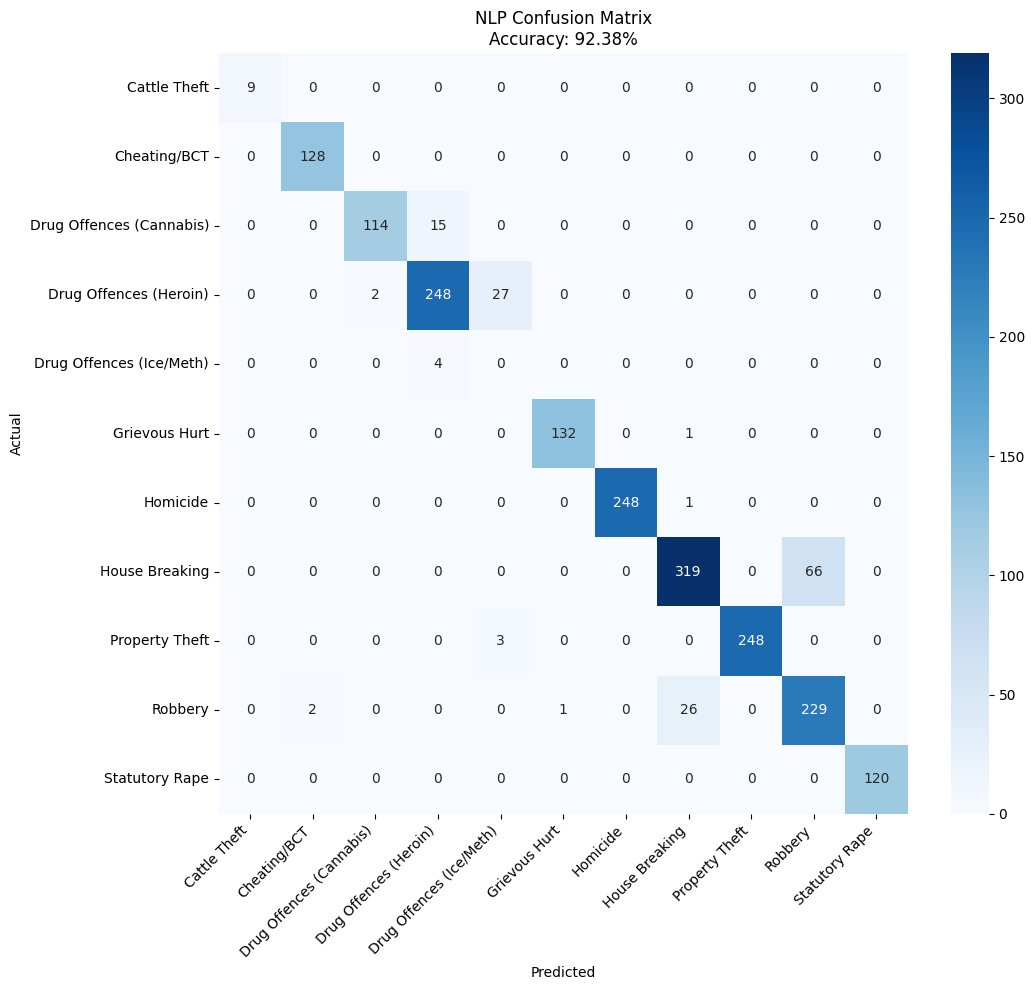

In [7]:
classes = pipeline.classes_
cm      = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(max(8, len(classes)), max(6, len(classes)-1)))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title(f"NLP Confusion Matrix\nAccuracy: {acc*100:.2f}%")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("nlp_confusion_matrix.png", dpi=150)
plt.show()

In [8]:
def predict_category(raw_text):
    cleaned  = clean_text(raw_text)
    category = pipeline.predict([cleaned])[0]
    proba    = pipeline.predict_proba([cleaned])[0]
    conf     = max(proba) * 100
    return category, conf

test_cases = [
    "occurred in Colombo district at a Residential during Night with Dark lighting victim was Female aged 18-25 offender drug history No",
    "occurred in Kandy district at a Public Space during Morning with Well-lit lighting offender had 3 prior offenses referred by Public",
    "occurred in Gampaha district at a Transport Hub during Evening with Poorly-lit lighting offender drug history Yes status Reported",
    "occurred in Galle district at a Commercial during Night with Dark lighting victim was Male aged 26-35 incident occurred on a holiday",
    "occurred in Jaffna district at a Residential during Night offender had 2 prior offenses status Cleared referred by Police",
]

print("🔍 Live Prediction Test:")
print("=" * 65)
for text in test_cases:
    cat, conf = predict_category(text)
    print(f"Input:     {text[:70]}...")
    print(f"Predicted: {cat}  ({conf:.1f}% confidence)")
    print("-" * 65)

🔍 Live Prediction Test:
Input:     occurred in Colombo district at a Residential during Night with Dark l...
Predicted: House Breaking  (89.5% confidence)
-----------------------------------------------------------------
Input:     occurred in Kandy district at a Public Space during Morning with Well-...
Predicted: Property Theft  (42.5% confidence)
-----------------------------------------------------------------
Input:     occurred in Gampaha district at a Transport Hub during Evening with Po...
Predicted: Drug Offences (Ice/Meth)  (58.2% confidence)
-----------------------------------------------------------------
Input:     occurred in Galle district at a Commercial during Night with Dark ligh...
Predicted: House Breaking  (38.6% confidence)
-----------------------------------------------------------------
Input:     occurred in Jaffna district at a Residential during Night offender had...
Predicted: House Breaking  (53.7% confidence)
-----------------------------------------------

In [9]:
os.makedirs("./trained", exist_ok=True)
joblib.dump(pipeline, "./trained/nlp_pipeline.pkl")
print("✅ NLP pipeline saved → ./trained/nlp_pipeline.pkl")
print(f"🎯 Final Accuracy: {acc*100:.2f}%")

✅ NLP pipeline saved → ./trained/nlp_pipeline.pkl
🎯 Final Accuracy: 92.38%
